# 06. Threshold Tuning and Healthcare Recommendations

In the previous notebook, Random Forest was selected as the best-performing model based on ROC-AUC and recall.

This notebook focuses on threshold tuning. Instead of using the default classification threshold of 0.50, different probability thresholds are tested to understand the tradeoff between precision and recall.

For 30-day readmission prediction, recall is especially important because missing high-risk patients may reduce opportunities for follow-up care, discharge planning, or additional monitoring.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

## Load Data and Best Model

The best model pipeline was saved in Notebook 05.

This pipeline includes both preprocessing and the trained Random Forest model.

In [2]:
data_path = "../data/processed/diabetic_data_preprocessed.csv"
model_path = "../models/best_model_pipeline.pkl"

df = pd.read_csv(data_path)
best_model = joblib.load(model_path)

df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,medical_specialty_grouped,readmitted_30_days
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,Other,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,Up,No,No,No,No,No,Ch,Yes,Unknown,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,Yes,Unknown,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,Up,No,No,No,No,No,Ch,Yes,Unknown,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,Steady,No,No,No,No,No,Ch,Yes,Unknown,0


In [3]:
df.shape

(101766, 44)

## Separate Features and Target

The same target variable is used:

- `1`: patient was readmitted within 30 days
- `0`: patient was not readmitted within 30 days

In [4]:
X = df.drop(columns=["readmitted_30_days"])
y = df["readmitted_30_days"]

X.shape, y.shape

((101766, 43), (101766,))

## Recreate Test Set

The same stratified train-test split from previous notebooks is recreated using the same random state.

This ensures that threshold tuning is performed on the same test set used for model comparison.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_test.shape, y_test.shape

((20354, 43), (20354,))

## Predicted Probabilities

The model outputs a predicted probability for each patient.

Threshold tuning converts these probabilities into class predictions using different cutoff values.

In [6]:
y_proba = best_model.predict_proba(X_test)[:, 1]

y_proba[:10]

array([0.51886723, 0.45365861, 0.55370739, 0.50630075, 0.54246332,
       0.43672328, 0.40930471, 0.44255998, 0.5651808 , 0.55514991])

In [7]:
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.6809


## Default Threshold Evaluation

By default, most classification models use a threshold of 0.50.

This means:

- predicted probability >= 0.50 → predict readmitted
- predicted probability < 0.50 → predict not readmitted

In [8]:
default_threshold = 0.50

y_pred_default = (y_proba >= default_threshold).astype(int)

print(classification_report(y_test, y_pred_default))

              precision    recall  f1-score   support

           0       0.93      0.66      0.77     18083
           1       0.18      0.61      0.28      2271

    accuracy                           0.65     20354
   macro avg       0.56      0.63      0.52     20354
weighted avg       0.85      0.65      0.71     20354



## Threshold Comparison

Different thresholds are tested to understand how precision and recall change.

Lowering the threshold usually increases recall because more patients are classified as high risk. However, precision often decreases because more low-risk patients are also flagged.

In [9]:
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1-score": f1_score(y_test, y_pred_threshold),
        "Predicted Positive Rate": y_pred_threshold.mean()
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1-score,Predicted Positive Rate
0,0.50,0.650339,0.181603,0.608542,0.279729,0.373882
1,0.45,0.320085,0.131686,0.910612,0.230097,0.771544
2,0.40,0.139137,0.114036,0.992074,0.204558,0.970669
3,0.35,0.111772,0.111597,1.000000,0.200787,0.999803
4,0.30,0.111575,0.111575,1.000000,0.200751,1.000000
5,0.25,0.111575,0.111575,1.000000,0.200751,1.000000
6,0.20,0.111575,0.111575,1.000000,0.200751,1.000000


## Precision-Recall Tradeoff by Threshold

This plot shows how precision and recall change as the classification threshold decreases.

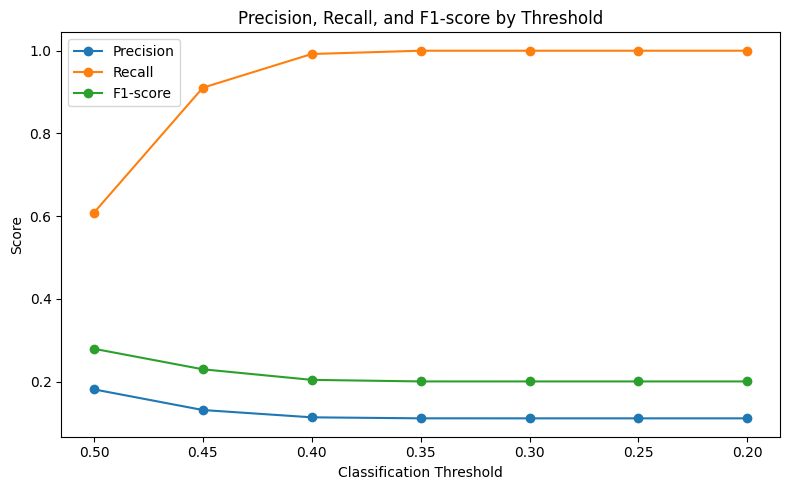

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1-score"], marker="o", label="F1-score")

plt.gca().invert_xaxis()
plt.title("Precision, Recall, and F1-score by Threshold")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

## Precision-Recall Curve

The precision-recall curve is useful for imbalanced classification because it focuses on performance for the positive class.

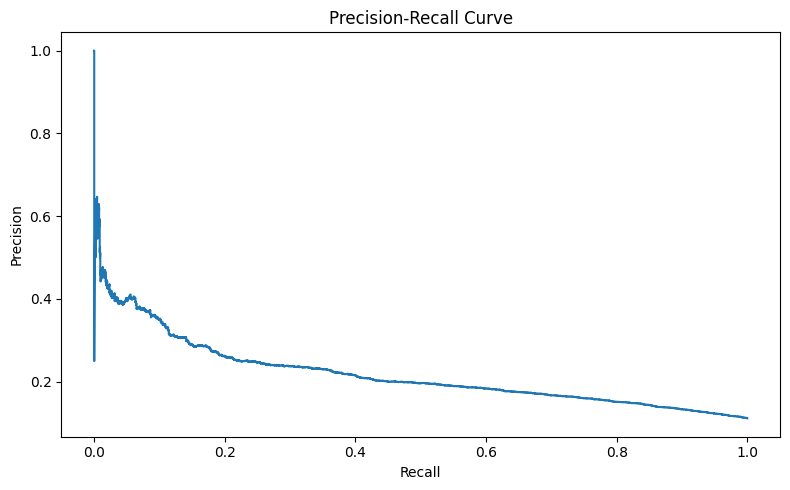

In [11]:
precision_values, recall_values, pr_thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))

plt.plot(recall_values, precision_values)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()

## Recommended Threshold

For this project, the recommended threshold should prioritize recall while keeping precision reasonable.

A lower threshold may be useful in healthcare screening because it identifies more patients who may be at risk of readmission.

However, the threshold should not be so low that almost every patient is flagged as high risk.

In [12]:
threshold_df

,Threshold,Accuracy,Precision,Recall,F1-score,Predicted Positive Rate
0,0.50,0.650339,0.181603,0.608542,0.279729,0.373882
1,0.45,0.320085,0.131686,0.910612,0.230097,0.771544
2,0.40,0.139137,0.114036,0.992074,0.204558,0.970669
3,0.35,0.111772,0.111597,1.000000,0.200787,0.999803
4,0.30,0.111575,0.111575,1.000000,0.200751,1.000000
5,0.25,0.111575,0.111575,1.000000,0.200751,1.000000
6,0.20,0.111575,0.111575,1.000000,0.200751,1.000000


In [20]:
recommended_threshold = 0.45

y_pred_recommended = (y_proba >= recommended_threshold).astype(int)

print(classification_report(y_test, y_pred_recommended))

              precision    recall  f1-score   support

           0       0.96      0.25      0.39     18083
           1       0.13      0.91      0.23      2271

    accuracy                           0.32     20354
   macro avg       0.54      0.58      0.31     20354
weighted avg       0.86      0.32      0.37     20354



## Confusion Matrix at Recommended Threshold

This confusion matrix shows model performance after applying the selected threshold.

Compared with the default threshold, the recommended threshold is expected to identify more true readmission cases, though it may also increase false positives.

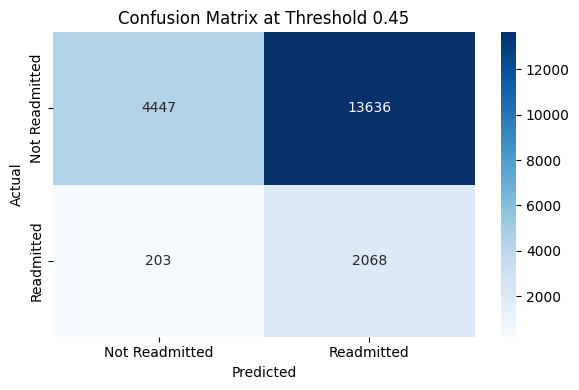

In [21]:
cm = confusion_matrix(y_test, y_pred_recommended)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Readmitted", "Readmitted"],
    yticklabels=["Not Readmitted", "Readmitted"]
)

plt.title(f"Confusion Matrix at Threshold {recommended_threshold}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Default vs Recommended Threshold

This comparison shows how model performance changes after threshold tuning.

In [22]:
comparison_rows = []

for label, threshold in {
    "Default Threshold": 0.50,
    "Recommended Threshold": recommended_threshold
}.items():
    y_pred_temp = (y_proba >= threshold).astype(int)
    
    comparison_rows.append({
        "Setting": label,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_temp),
        "Precision": precision_score(y_test, y_pred_temp, zero_division=0),
        "Recall": recall_score(y_test, y_pred_temp),
        "F1-score": f1_score(y_test, y_pred_temp),
        "Predicted Positive Rate": y_pred_temp.mean()
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df

,Setting,Threshold,Accuracy,Precision,Recall,F1-score,Predicted Positive Rate
0,Default Threshold,0.50,0.650339,0.181603,0.608542,0.279729,0.373882
1,Recommended Threshold,0.45,0.320085,0.131686,0.910612,0.230097,0.771544


## Create Test-Set Risk Score Dataset

A test-set risk score dataset is created to show patient-level predicted probabilities and threshold-based predictions.

This is useful for explaining how the model could support risk stratification.

In [23]:
test_risk_df = X_test.copy()

test_risk_df["actual_readmitted_30_days"] = y_test.values
test_risk_df["predicted_readmission_risk"] = y_proba
test_risk_df["predicted_at_default_threshold"] = (y_proba >= 0.50).astype(int)
test_risk_df["predicted_at_recommended_threshold"] = y_pred_recommended

test_risk_df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,medical_specialty_grouped,actual_readmitted_30_days,predicted_readmission_risk,predicted_at_default_threshold,predicted_at_recommended_threshold
99195,Caucasian,Female,[80-90),1,1,7,4,40,0,17,...,No,No,No,Ch,Yes,Unknown,0,0.518867,1,1
63319,AfricanAmerican,Male,[60-70),1,1,7,5,29,3,22,...,No,No,No,No,Yes,Unknown,0,0.453659,0,1
64536,Caucasian,Female,[70-80),3,22,1,2,26,2,29,...,No,No,No,Ch,Yes,Other,0,0.553707,1,1
13039,Caucasian,Male,[50-60),3,18,1,5,43,3,34,...,No,No,No,No,No,Unknown,1,0.506301,1,1
37502,AfricanAmerican,Male,[70-80),6,22,17,12,77,6,38,...,No,No,No,Ch,Yes,Other,1,0.542463,1,1


## Create Risk Groups

Predicted probabilities are grouped into low, medium, and high-risk categories for easier communication.

These risk groups are for exploratory analytics and are not clinically validated.

In [27]:
test_risk_df["risk_group"] = pd.qcut(
    test_risk_df["predicted_readmission_risk"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"],
    duplicates="drop"
)

test_risk_df["risk_group"].value_counts()

risk_group
Low Risk       6785
High Risk      6785
Medium Risk    6784
Name: count, dtype: int64

## Readmission Rate by Risk Group

This table checks whether higher predicted risk groups have higher actual readmission rates.

In [28]:
risk_group_summary = test_risk_df.groupby("risk_group").agg(
    patient_count=("actual_readmitted_30_days", "count"),
    actual_readmission_rate=("actual_readmitted_30_days", "mean"),
    avg_predicted_risk=("predicted_readmission_risk", "mean")
).reset_index()

risk_group_summary

,risk_group,patient_count,actual_readmission_rate,avg_predicted_risk
0,Low Risk,6785,0.049079,0.435148
1,Medium Risk,6784,0.097435,0.484379
2,High Risk,6785,0.188209,0.534081


Because the model’s predicted probabilities are concentrated within a narrow range, fixed probability cutoffs did not create meaningful risk groups. Quantile-based grouping was used instead to separate patients into low-, medium-, and high-risk groups based on relative predicted risk.

The observed readmission rate increases across the three groups, which suggests that the model is useful for ranking patients by readmission risk.

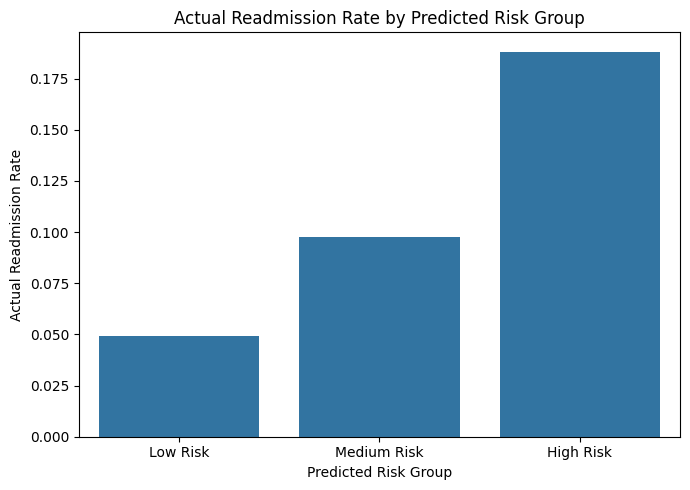

In [29]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=risk_group_summary,
    x="risk_group",
    y="actual_readmission_rate"
)

plt.title("Actual Readmission Rate by Predicted Risk Group")
plt.xlabel("Predicted Risk Group")
plt.ylabel("Actual Readmission Rate")
plt.tight_layout()
plt.show()

## Healthcare Recommendation

The threshold tuning analysis shows that the default threshold of 0.50 may not be the best choice for a healthcare readmission screening use case.

A lower threshold can improve recall, allowing the model to identify more patients who are actually readmitted within 30 days.

For a hospital care management workflow, this type of model could be used as an early screening tool to prioritize patients for:

- Discharge planning
- Follow-up phone calls
- Medication review
- Care coordination
- Post-discharge monitoring

The model should not be used as a standalone clinical decision-making tool. Instead, it should support healthcare teams by highlighting patients who may benefit from additional review.

## Save Threshold-Tuned Risk Scores

The test-set risk score file is saved for future review and dashboarding.

In [30]:
output_path = "../data/processed/threshold_tuned_test_risk_scores.csv"

test_risk_df.to_csv(output_path, index=False)

print(f"Threshold-tuned risk score dataset saved to: {output_path}")

Threshold-tuned risk score dataset saved to: ../data/processed/threshold_tuned_test_risk_scores.csv


## Summary

This notebook focused on threshold tuning for the selected Random Forest model.

Completed steps:

- Loaded the best saved model from Notebook 05
- Recreated the same test set used in previous notebooks
- Generated predicted readmission probabilities
- Evaluated the default 0.50 classification threshold
- Compared multiple thresholds
- Visualized the precision-recall tradeoff
- Selected a recommended threshold for healthcare screening
- Compared default and recommended threshold performance
- Created patient-level risk scores and risk groups
- Saved threshold-tuned risk scores for future dashboarding

The results show that threshold selection has a major impact on how many readmitted patients are identified.For exploratory healthcare screening, a lower threshold may be useful when the goal is to improve recall, but this comes with more false positives.